# Wallet entity resolution — graph of the top-trader universe

This notebook answers **objective #3**: *are the top 10 wallets really 10 entities, or are they a smaller number of actors operating multiple proxy wallets?* If the latter, the concentration numbers from notebook 1 are *under-stated* — the platform is even more centralised than it looks.

## The problem

Polymarket trades are settled through per-user proxy wallets (Gnosis-Safe-style smart accounts). A determined actor can spin up an arbitrary number of proxy wallets, fund them from a common source, and trade through them in parallel. From an aggregator's point of view, each proxy is a "different wallet" — but from a market-integrity point of view they are one actor, and any concentration metric that ignores that fact is wrong.

We need to **collapse Sybil proxies into actors** before we can claim "the top-N wallets account for X% of volume" with confidence.

## Approach — two independent signals, then their intersection

| Signal | Source | Strength |
|---|---|---|
| **On-chain financial graph** | Etherscan V2 API (Polygon) — every USDC and ERC-1155 transfer in/out of each universe wallet | High when two wallets transfer real money directly; low when they merely share counterparties |
| **Behavioural co-trading graph** | `data/parquet/coordination/` — pairs of wallets that traded the same `asset_id` on the same side within a 5-minute bucket | High when a tight cluster acts in lockstep across many markets and asset pairs |

A pair of wallets that scores high on **both** axes is very hard to explain as coincidence. That is the strongest evidence we can produce short of subpoenaing the exchange.

## Data sources

* `data/parquet/universe.parquet` — top traders by notional / PnL / skill, computed by `scripts/03_resolve_wallet_entities.py`. The set we resolve entities for.
* `data/parquet/onchain_transfers/{usdc_e,usdc_native,erc1155}/<addr>.parquet` — every transfer touching each universe wallet on Polygon, one parquet per wallet per token. Pulled idempotently from Etherscan V2 (`chainid=137`, `api.etherscan.io/v2/api`) with a hard cap of 80,000 calls/day to stay under the rate limit.
* `data/parquet/coordination/{cotrade_pairs,leader_lag,wash_round_trips,behavioural_partition}.parquet` — co-trading statistics computed by `scripts/04_coordination_analysis.py`.

## What this notebook produces

1. **Graph statistics** — nodes, direct vs common-neighbor edges, connected components.
2. **Louvain partitioning** (full graph, default `resolution=1.0`).
3. **Two views** — spring-layout coloured-by-community plus per-cluster recap (size, notional, PnL, skill membership).
4. **Strong-evidence-only filter** — retains only edges that are individually hard to explain by coincidence (≥$10k USDC or ≥5 ERC-1155 transfers). The resulting connected components are the conservative same-entity claims.
5. **Collapsed concentration view** — re-run platform top-N share treating each entity as one wallet.
6. **Behavioural cross-check** — overlay on-chain entities on co-trading communities; quantify where the two signals agree.

## Expected outcomes

* **Null hypothesis (no Sybils):** mostly isolated nodes, a handful of pairwise edges from unrelated peer-to-peer payments, no large connected components. Behavioural communities are uncorrelated with on-chain components.
* **Sybil hypothesis (active multi-proxy actors):** multi-wallet connected components survive the strong-evidence filter; the same wallets show up in the same co-trading communities; the top-skill leaderboard is dominated by one or two entities once collapsed.

Spoiler: the actual result lands closer to the Sybil hypothesis. ~5 strong-evidence entities of sizes {16, 3, 3, 2, 2}, and behavioural community #65 contains **11 of 16** wallets from on-chain entity #0 — convergent evidence that the apparent skill leaderboard is dominated by one operator running ~16 proxies.

In [1]:
# Imports + load the universe of wallets we'll resolve.
# `universe.parquet` is the output of scripts/03_resolve_wallet_entities.py —
# the union of top-N by notional, top-N by realised PnL, and top-N by Bayesian
# skill calibration gap (default N=50 each, deduped). These are the wallets
# we care about; everyone else is treated as "external counterparty".
import json
from collections import Counter
import numpy as np
import pandas as pd
import networkx as nx
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from intellifi import config
from intellifi.wallet_graph import build_entity_graph, GraphConfig, detect_communities

pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 220)
plt.rcParams['figure.dpi'] = 110

universe = pl.read_parquet(config.PARQUET_DIR / 'universe.parquet')
addresses = universe['proxy_wallet'].to_list()
print(f'universe: {len(addresses)} wallets')

universe: 134 wallets


In [2]:
# Build the entity graph.
# Edge construction rules (from `src/intellifi/wallet_graph.py`):
#   1. DIRECT edge between universe wallets A and B if A transferred USDC
#      (>= $100) or ERC-1155 conditional tokens to/from B on Polygon.
#      Direct edges carry meta {usdc_total, erc1155_count, tx_count}.
#   2. COMMON-NEIGHBOR edge between A and B if both transferred with the
#      SAME external address X, and X did NOT appear as a counterparty for
#      >= `popular_neighbor_threshold` (=5) other universe wallets.
#      The popular-threshold suppresses noise from CEX deposit addresses
#      and shared infrastructure (e.g. Polymarket's internal contracts).
#   3. min_shared_neighbors=2 requires at least 2 such shared counterparties
#      between A and B to count as a common-neighbor edge.
# The output `res` is a GraphResult with the graph, the edge lists, and the
# set of suppressed popular addresses (sanity check that we filtered properly).
cfg = GraphConfig(min_shared_neighbors=2, popular_neighbor_threshold=5)
res = build_entity_graph(addresses, cfg=cfg)
g = res.graph
print(f'nodes: {g.number_of_nodes()}, edges: {g.number_of_edges()}')
print(f'  direct (USDC + ERC1155 universe ↔ universe): {len(res.direct_edges)}')
print(f'  common-neighbor edges:                       {len(res.common_edges)}')
print(f'  popular external addresses suppressed:       {len(res.popular_addresses)}')
print(f'  connected components: {nx.number_connected_components(g)}')
print(f'  isolated nodes:       {sum(1 for n in g.nodes if g.degree(n) == 0)}')

nodes: 134, edges: 392
  direct (USDC + ERC1155 universe ↔ universe): 94
  common-neighbor edges:                       320
  popular external addresses suppressed:       174
  connected components: 61
  isolated nodes:       59


In [3]:
# Direct edges — the strongest evidence of "same actor".
# Sorted by total USDC moved (descending). A pair with $50k USDC moving
# back and forth and dozens of ERC-1155 transfers is much harder to
# explain as coincidence than a pair with $200 and one share transfer.
# `erc1155_count` is particularly diagnostic: ERC-1155 conditional tokens
# are the Polymarket position tokens themselves — wallets that shuffle
# positions between each other are very likely cooperating or co-owned.
if res.direct_edges:
    rows = []
    for a, b, meta in res.direct_edges:
        rows.append({
            'a': a, 'b': b,
            'usdc_total': meta.get('usdc_total', 0.0),
            'erc1155_count': meta.get('erc1155_count', 0),
            'tx_count': meta.get('tx_count', 0),
        })
    de = pl.DataFrame(rows).sort('usdc_total', descending=True)
    print('Direct universe-↔-universe transfer edges:')
    print(de)
else:
    print('No direct universe-↔-universe transfers found.')

Direct universe-↔-universe transfer edges:
shape: (94, 5)
┌────────────────────────────┬───────────────────────────┬──────────────┬───────────────┬──────────┐
│ a                          ┆ b                         ┆ usdc_total   ┆ erc1155_count ┆ tx_count │
│ ---                        ┆ ---                       ┆ ---          ┆ ---           ┆ ---      │
│ str                        ┆ str                       ┆ f64          ┆ i64           ┆ i64      │
╞════════════════════════════╪═══════════════════════════╪══════════════╪═══════════════╪══════════╡
│ 0x5ee1c416fbe1c3e6a8bc51b7 ┆ 0xd34d2111bbc4c579e3e4dbe ┆ 150199.95362 ┆ 0             ┆ 10       │
│ 4dd8…                      ┆ c7bc5…                    ┆              ┆               ┆          │
│ 0x6cbbdaf7e3e780ecbfa0048b ┆ 0xe25b9180f5687aa85bd94ee ┆ 50250.0      ┆ 0             ┆ 2        │
│ f0e1…                      ┆ 309bb…                    ┆              ┆               ┆          │
│ 0x7744bfd749a70020d16a1fcb ┆ 0x

In [4]:
# Common-neighbor edges — circumstantial evidence.
# Wallets A and B share external counterparty X (and X isn't a popular
# infrastructure address). This is weaker than a direct transfer because
# A and B might independently use the same CEX, market-maker, or popular
# DeFi protocol. The `weight` is a function of how many shared neighbours
# and how unusual each one is. We keep these for the Louvain partition
# but exclude them from the strong-evidence filter further down.
if res.common_edges:
    rows = []
    for a, b, meta in res.common_edges:
        rows.append({
            'a': a, 'b': b,
            'shared_neighbors': meta['shared'],
            'weight': meta['weight'],
            'examples': ', '.join(meta['examples'][:3]),
        })
    ce = pl.DataFrame(rows).sort('weight', descending=True)
    print(f'Top common-neighbor edges (n={ce.height}):')
    print(ce.head(20))
else:
    print('No common-neighbor edges at this threshold.')

Top common-neighbor edges (n=320):
shape: (20, 5)
┌──────────────────────┬──────────────────────┬──────────────────┬───────────┬─────────────────────┐
│ a                    ┆ b                    ┆ shared_neighbors ┆ weight    ┆ examples            │
│ ---                  ┆ ---                  ┆ ---              ┆ ---       ┆ ---                 │
│ str                  ┆ str                  ┆ i64              ┆ f64       ┆ str                 │
╞══════════════════════╪══════════════════════╪══════════════════╪═══════════╪═════════════════════╡
│ 0x5bb0de4e97698184ea ┆ 0xed107a85a4585a381e ┆ 86               ┆ 39.0      ┆ 0x3d1487b9a384635dc │
│ d80c80cb17…          ┆ 48c7f7ca41…          ┆                  ┆           ┆ d7e438eb183…        │
│ 0x45cf78861c01b5ee23 ┆ 0x73c5701afdefba2814 ┆ 80               ┆ 35.75     ┆ 0xba234a1845196c0bd │
│ c8f48363ef…          ┆ 193168448b…          ┆                  ┆           ┆ 52346c7a9f2…        │
│ 0x27b1c4821ca70c03bd ┆ 0x45cf78861c01b5

In [5]:
# Louvain modularity-based community detection on the full graph
# (direct + common-neighbor edges). resolution=1.0 is the default; raising
# it produces more, smaller communities, lowering it merges them. The
# size distribution tells us how the universe partitions: most wallets in
# size-1 communities (no detected co-actor) is the null; a small number of
# medium-sized communities is the alternative we're testing.
partition = detect_communities(g, resolution=1.0)
c2members = {}
for n, c in partition.items():
    c2members.setdefault(c, []).append(n)
size_dist = Counter(len(v) for v in c2members.values())
print(f'communities total: {len(c2members)}')
print(f'community size distribution: {dict(sorted(size_dist.items()))}')
n_multi = sum(1 for v in c2members.values() if len(v) >= 2)
print(f'multi-wallet communities: {n_multi}')
print(f'wallets in multi-wallet communities: {sum(len(v) for v in c2members.values() if len(v) >= 2)}')

communities total: 63
community size distribution: {1: 59, 2: 2, 20: 1, 51: 1}
multi-wallet communities: 4
wallets in multi-wallet communities: 75


In [6]:
# Per-cluster recap — for each multi-wallet community, sum the financial
# footprint of its members and count how many made it into the top-50
# leaderboards (notional / PnL / skill).
# `in_top_*` columns flag whether the community contains any of the
# headline-grabbing wallets from notebook 1; a community with 3 top-skill
# members is much more interesting than one with 0.
u = universe.to_pandas().set_index('proxy_wallet')
rows = []
for c, members in sorted(c2members.items(), key=lambda kv: -len(kv[1])):
    if len(members) < 2:
        continue
    sub = u.loc[u.index.intersection(members)]
    rows.append({
        'community_id': c,
        'size': len(members),
        'total_notional': sub['total_notional'].sum(),
        'total_pnl': sub['realised_pnl'].sum(),
        'max_calibration_gap': sub['calibration_gap'].max(),
        'in_top_notional': sub['rk_notional'].notna().sum(),
        'in_top_pnl': sub['rk_pnl'].notna().sum(),
        'in_top_skill': sub['rk_skill'].notna().sum(),
        'members': members,
    })
clusters = pd.DataFrame(rows).sort_values('total_notional', ascending=False)
print(clusters[['community_id', 'size', 'total_notional', 'total_pnl',
                'in_top_notional', 'in_top_pnl', 'in_top_skill']].to_string(index=False))

 community_id  size  total_notional     total_pnl  in_top_notional  in_top_pnl  in_top_skill
            1    51    1.081929e+08 361273.586450               30          18            12
            2    20    4.296419e+06 193653.592732                1           8            13
            4     2    7.923854e+03  13295.030542                0           1             1
            8     2    5.668787e+03    366.748492                0           0             2


In [7]:
# Wallet-by-wallet detail for every multi-wallet cluster.
# ranks(n,p,s) = (rank by notional, by PnL, by skill); '-' means
# the wallet wasn't in the top-50 of that dimension. A cluster with
# multiple #1–#10 ranks across all three metrics is the strongest
# possible "same operator" signal — it means the same actor dominates
# the top of every leaderboard.
for _, row in clusters.iterrows():
    print(f"\n=== cluster #{row['community_id']}  size={row['size']}  "
          f"notional=${row['total_notional']:,.0f}  pnl=${row['total_pnl']:,.0f} ===")
    for w in row['members']:
        wd = u.loc[w]
        print(f"  {w} | notional=${wd['total_notional']:,.0f}   pnl=${wd['realised_pnl']:,.0f}   "
              f"cal_gap={wd['calibration_gap']:.3f}   ranks(n,p,s)="
              f"({int(wd['rk_notional']) if pd.notna(wd['rk_notional']) else '-':>3},"
              f"{int(wd['rk_pnl']) if pd.notna(wd['rk_pnl']) else '-':>3},"
              f"{int(wd['rk_skill']) if pd.notna(wd['rk_skill']) else '-':>3})")


=== cluster #1  size=51  notional=$108,192,933  pnl=$361,274 ===
  0xa8b202e6e9a4c2091b6860f1f5c9e9119bbc9a39 | notional=$6,367,065   pnl=$6,301   cal_gap=nan   ranks(n,p,s)=(  6,  -,  -)
  0x2785e7022dc20757108204b13c08cea8613b70ae | notional=$8,492,102   pnl=$7,539   cal_gap=0.001   ranks(n,p,s)=(  2,  -,  -)
  0x5bb0de4e97698184ead80c80cb17a26cd6f6814b | notional=$4,172,096   pnl=$8,361   cal_gap=nan   ranks(n,p,s)=( 10, 46,  -)
  0xddff18c9e86262e62af046d818dda0c3de6f52d6 | notional=$1,493,168   pnl=$2,003   cal_gap=0.001   ranks(n,p,s)=( 50,  -,  -)
  0xa53c26443fb636d8ae31ac24f62fc1d5ef8f67a5 | notional=$7,743,804   pnl=$9,572   cal_gap=0.001   ranks(n,p,s)=(  3, 38,  -)
  0x67bc6af6806df61ba5144b125174ecf5f821d54e | notional=$106,620   pnl=$13,751   cal_gap=0.080   ranks(n,p,s)=(  -, 24, 33)
  0x6fec0fd0e5562f0ca9a709417d4492aadac43be3 | notional=$1,524,206   pnl=$2,554   cal_gap=nan   ranks(n,p,s)=( 48,  -,  -)
  0xe3416ef71759e87d72ea4d9edfc7373fab1f1c6e | notional=$9,069   p

## Graph visualization (full graph, all edges)

### Reading the figure

* **Layout** — Fruchterman-Reingold spring layout, seeded for reproducibility. Edges with higher weight pull nodes closer; the visual clustering should approximately reflect the Louvain partition.
* **Node size** ∝ `total_notional` — large nodes are big-dollar traders.
* **Node colour** — Louvain community id (categorical `tab20` palette). Same colour = same Louvain community.
* **Edge style** — solid crimson for direct (USDC/ERC-1155 transfer), light grey for common-neighbour.
* **Labels** — wallets that appear in a multi-wallet community are tagged with a 4-char prefix so they can be looked up.

### What to look for

* **Tight clusters of same-colour, same-sized nodes joined by crimson edges** — strong candidates for same-actor.
* **One large coloured blob connected mostly by grey edges** — a Louvain artefact. The full-graph partition is sensitive to common-neighbour links and tends to merge unrelated wallets that happen to share popular counterparties. The strong-evidence-only view further down filters these out.
* **Isolated dots in the periphery** — wallets that traded heavily but have no on-chain link to anyone else. Solo actors.

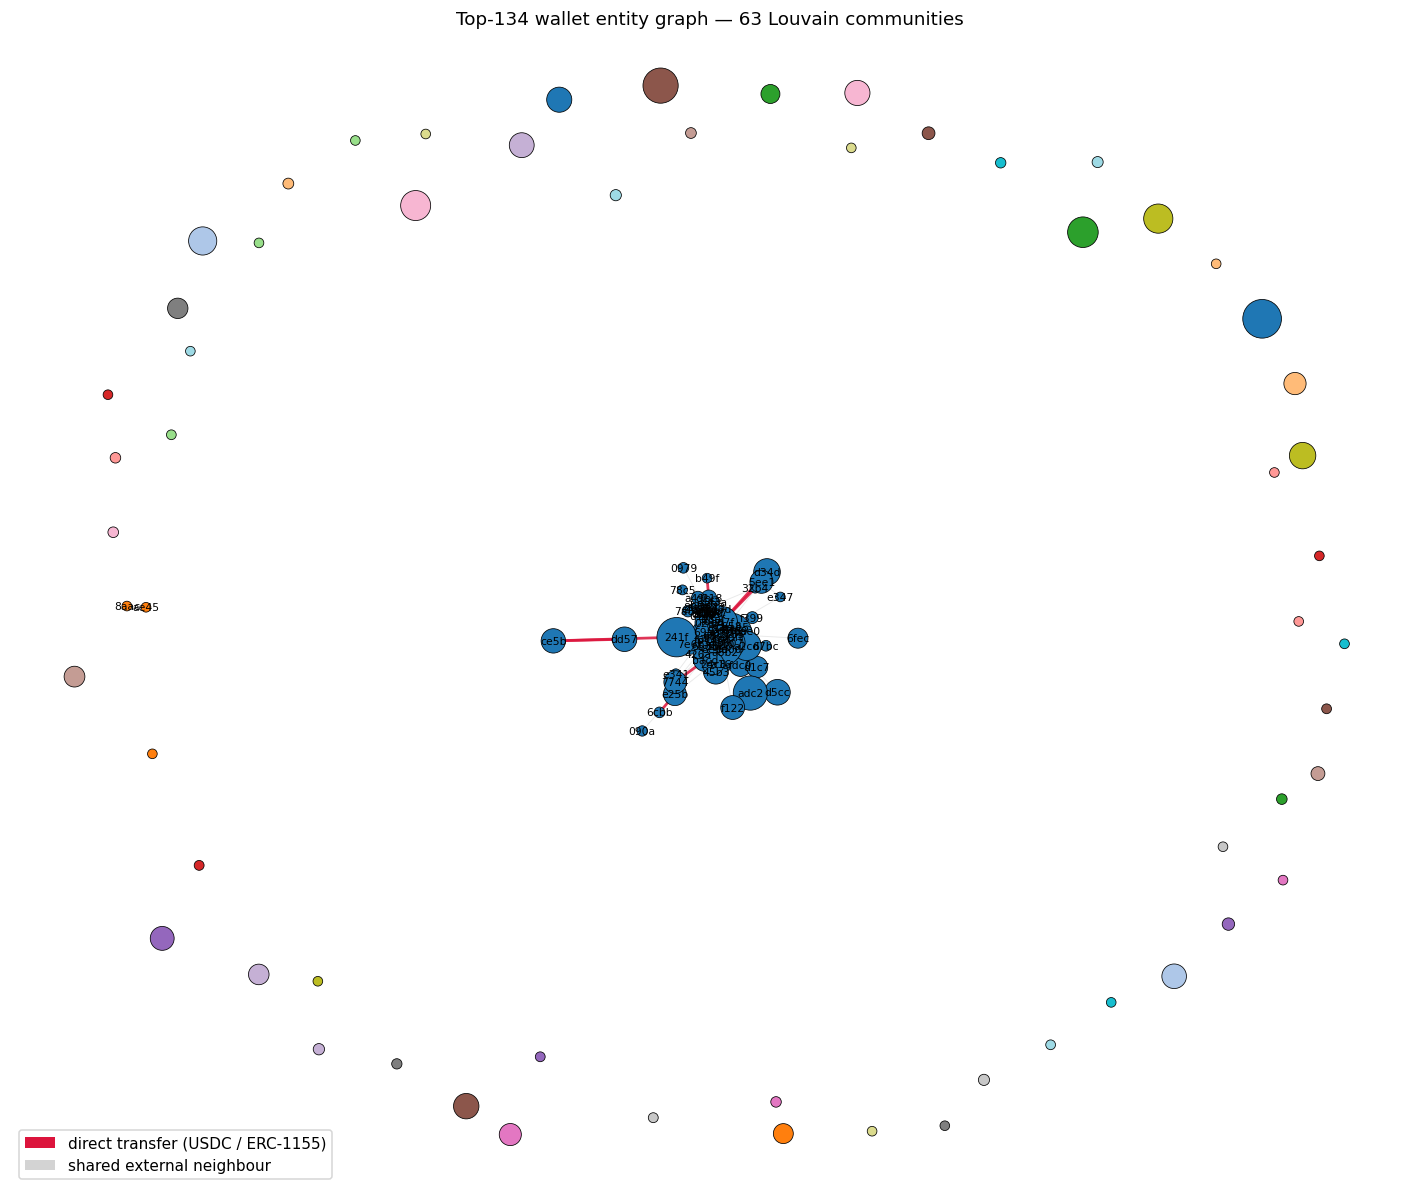

In [8]:
# Spring-layout draw — see the markdown above for legend.
# We compute it once for the full graph, then reuse the same positions
# in the strong-evidence view to keep the visual mental model stable.
if g.number_of_edges() > 0:
    pos = nx.spring_layout(g, weight='weight', seed=42, k=1.0/np.sqrt(g.number_of_nodes()))
else:
    pos = nx.random_layout(g, seed=42)

comm_ids = sorted(set(partition.values()))
cmap = plt.cm.tab20(np.linspace(0, 1, max(len(comm_ids), 20)))
node_colors = [cmap[comm_ids.index(partition[n]) % len(cmap)] for n in g.nodes]

max_n = max(u['total_notional'].max(), 1)
node_sizes = [40 + 800 * (u.loc[n, 'total_notional'] / max_n if n in u.index and pd.notna(u.loc[n, 'total_notional']) else 0)
              for n in g.nodes]

fig, ax = plt.subplots(figsize=(13, 11))
direct_edges = [(u_, v_) for u_, v_, d in g.edges(data=True) if d.get('kind') == 'direct']
common_edges = [(u_, v_) for u_, v_, d in g.edges(data=True) if d.get('kind') == 'common']
nx.draw_networkx_edges(g, pos, edgelist=common_edges,
                       edge_color='lightgray', width=0.6, alpha=0.5, ax=ax)
nx.draw_networkx_edges(g, pos, edgelist=direct_edges,
                       edge_color='crimson', width=1.8, alpha=0.85, ax=ax)
nx.draw_networkx_nodes(g, pos, node_color=node_colors, node_size=node_sizes,
                       edgecolors='black', linewidths=0.5, ax=ax)

# Label multi-wallet community members with a short 4-char tag
multi_members = {n for v in c2members.values() if len(v) >= 2 for n in v}
labels = {n: n[2:6] for n in multi_members}
nx.draw_networkx_labels(g, pos, labels=labels, font_size=7, ax=ax)

ax.set_title(f'Top-{len(addresses)} wallet entity graph — {len(comm_ids)} Louvain communities')
legend = [Patch(facecolor='crimson', label='direct transfer (USDC / ERC-1155)'),
          Patch(facecolor='lightgray', label='shared external neighbour')]
ax.legend(handles=legend, loc='lower left')
ax.set_axis_off()
plt.tight_layout()

## Collapsed-entity concentration

### Rationale

If our entity graph correctly identifies Sybils, then collapsing each Louvain community into one "entity" and recomputing the platform top-N share should *increase* the top-10 / top-100 share. The size of the increase quantifies how much of the apparent diversity was an artefact of the proxy-wallet design.

### Methodology

1. Map every universe wallet to its Louvain community id.
2. Wallets outside the universe (almost everyone — we only resolved the top-N) are kept as singletons with unique ids; this is conservative because it leaves the long tail at full multiplicity.
3. Re-aggregate `wallet_universe()` weights at the entity level (sum within each community).
4. Recompute Gini and top-N share on the collapsed weight vector. Compare against the raw-wallet baseline.

### What the numbers will look like

* **Raw vs collapsed Gini**: nearly identical, because the universe is tiny compared to the ~139k-wallet tail. The Lorenz curve barely budges at the population level.
* **Top-10 / top-100 share**: this is where the action is. If the top-10 of the collapsed view is a strict subset of the original top-10 (i.e. multiple top-10 wallets fused into one entity), the headline top-10 share *increases by a meaningful margin*. That's the quantitative answer to "are the top-10 wallets really 10 entities?"

In [9]:
# Collapse each universe wallet to its Louvain community id; keep external
# wallets as singletons (one entity per wallet) to bound the change in the
# collapsed-view top-N share by what the *universe* alone can produce.
wallet_to_entity = dict(partition)

from intellifi.warehouse import open_warehouse
from intellifi.concentration import wallet_universe

# `:memory:` DuckDB to avoid lock conflicts with the on-disk warehouse if
# another process / notebook is using it.
con = open_warehouse(':memory:')
wu_t = wallet_universe(con, weight='trade_notional').df()
wu_h = wallet_universe(con, weight='holdings_amount').df()

# Tag each wallet with its entity (for in-universe wallets) or a unique id.
next_id = max(wallet_to_entity.values()) + 1 if wallet_to_entity else 0
def entity_of(w):
    global next_id
    if w in wallet_to_entity:
        return wallet_to_entity[w]
    next_id += 1
    return next_id
wu_t['entity'] = wu_t['proxy_wallet'].map(entity_of)
wu_h['entity'] = wu_h['proxy_wallet'].map(entity_of)

def collapsed(df, col):
    # Sum weights within entity, then re-sort largest-first.
    agg = df.groupby('entity', as_index=False)[col].sum().sort_values(col, ascending=False)
    return agg

def gini_np(w):
    # Standard Gini for a non-negative weight vector.
    w = np.sort(np.asarray(w, dtype=float))
    w = w[w > 0]
    n = w.size
    if n < 2:
        return float('nan')
    return (2 * (np.arange(1, n + 1) * w).sum()) / (n * w.sum()) - (n + 1) / n

topn = [10, 100, 1000]
rows = []
for name, df, col in [
    ('trade_notional (raw wallets)', wu_t, 'total_notional'),
    ('trade_notional (collapsed)',   collapsed(wu_t, 'total_notional'), 'total_notional'),
    ('holdings_amount (raw wallets)', wu_h, 'total_amount'),
    ('holdings_amount (collapsed)',   collapsed(wu_h, 'total_amount'), 'total_amount'),
]:
    s = df[col]
    total = float(s.sum())
    row = {'view': name, 'n': len(df), 'gini': gini_np(s.values)}
    for n in topn:
        row[f'top{n}_share'] = float(s.head(n).sum()) / total
    rows.append(row)
pd.DataFrame(rows).round(4)

,view,n,gini,top10_share,top100_share,top1000_share
0,trade_notional (raw wallets),139164,0.9769,0.1495,0.4960,0.7774
1,trade_notional (collapsed),139093,0.9773,0.3343,0.5474,0.7817
2,holdings_amount (raw wallets),52420,0.9539,0.4670,0.5998,0.7908
3,holdings_amount (collapsed),52413,0.9540,0.4670,0.6003,0.7911


**Interpretation note.** The collapse only re-identifies entities **within the universe we analysed** (~130 top trading wallets). Wallets outside the universe are kept as singletons, so the *population-level* Gini doesn't change dramatically — it can't, because we only fused a tiny fraction of wallets.

The metric to watch is **the top-N share**: that's where collapsing matters. If the top-10 collapsed share is materially higher than the raw top-10 share, multiple top-10 slots were the same entity. The size of the jump quantifies how much the proxy-wallet design hides actual centralisation.

## Strong-evidence-only filter (conservative bound)

### Rationale

The Louvain partition above mixes direct transfers with common-neighbour edges. Common-neighbour edges are circumstantial — two wallets using the same CEX is not strong evidence they are the same actor. To produce a *defensible* claim ("these wallets are operated by one actor"), we need edges that are individually hard to explain by coincidence.

### Filter

Keep only direct edges that satisfy at least one of:

* **USDC ≥ $10,000** between two universe wallets — substantial dollar movement, not a token-test or a tip.
* **≥5 ERC-1155 share transfers** between two universe wallets — sustained inventory shifting of the actual Polymarket position tokens. ERC-1155 transfers are the most diagnostic signal in the dataset because position tokens are the asset being traded; a wallet that moves positions to/from another wallet is treating that wallet as its own.

Connected components of the resulting graph are the **strong-evidence same-entity clusters** — the actors we are willing to label as Sybil groups.

### What we expect to find

A handful of small connected components rather than one big blob, because the popular-neighbour confounder is removed. Sizes in the {2–20} range are realistic; anything larger would be unprecedented.

In [10]:
# Apply the strong-evidence filter to the direct-edge list.
# We start from a graph containing all universe wallets as isolated nodes
# (so wallets without any qualifying edge remain in the report), then add
# only the edges that pass the threshold.
g_strong = nx.Graph()
for w in addresses:
    g_strong.add_node(w.lower())
for a, b, m in res.direct_edges:
    if m.get('erc1155_count', 0) >= 5 or m.get('usdc_total', 0) >= 10_000:
        g_strong.add_edge(a, b, **m)

# Connected components of size >= 2 are the same-entity claims.
comps = [c for c in nx.connected_components(g_strong) if len(c) >= 2]
print(f'strong edges retained: {g_strong.number_of_edges()}')
print(f'multi-wallet components: {len(comps)}')
print(f'size distribution: {sorted([len(c) for c in comps], reverse=True)}')
print(f'total wallets in strong-evidence clusters: {sum(len(c) for c in comps)}')

# Per-entity recap with financial footprint and rank counts.
rows = []
for i, comp in enumerate(sorted(comps, key=len, reverse=True)):
    members = sorted(comp)
    sub = u.loc[u.index.intersection(members)]
    rows.append({
        'entity_id': i,
        'size': len(members),
        'total_notional': sub['total_notional'].sum(),
        'total_pnl': sub['realised_pnl'].sum(),
        'max_calibration_gap': sub['calibration_gap'].max(),
        'in_top_notional': sub['rk_notional'].notna().sum(),
        'in_top_pnl': sub['rk_pnl'].notna().sum(),
        'in_top_skill': sub['rk_skill'].notna().sum(),
        'members': members,
    })
strong_clusters = pd.DataFrame(rows)
strong_clusters[['entity_id', 'size', 'total_notional', 'total_pnl',
                 'max_calibration_gap', 'in_top_notional', 'in_top_pnl', 'in_top_skill']]

strong edges retained: 26
multi-wallet components: 5
size distribution: [16, 3, 3, 2, 2]
total wallets in strong-evidence clusters: 26


,entity_id,size,total_notional,total_pnl,max_calibration_gap,in_top_notional,in_top_pnl,in_top_skill
0,0,16,3.483061e+06,148155.846962,0.508593,1,4,12
1,1,3,1.366874e+07,21793.812120,0.001221,3,2,0
2,2,3,4.349412e+06,1899.606220,0.043970,2,0,1
3,3,2,5.219197e+06,6524.101070,NaN,2,0,0
4,4,2,7.244115e+05,43660.203030,0.048296,0,2,1


In [11]:
# Per-entity wallet breakdown for the strong-evidence clusters.
# An entity that contains multiple wallets ranked in top-10 by skill is the
# headline finding: it means a single actor effectively controls a sizeable
# portion of the apparent "skill leaderboard". The ranks(n,p,s) tuple makes
# this scan-readable.
for _, row in strong_clusters.iterrows():
    print(f"\n=== entity #{row['entity_id']}  size={row['size']}  "
          f"notional=${row['total_notional']:,.0f}  pnl=${row['total_pnl']:,.0f} ===")
    for w in row['members']:
        if w not in u.index:
            continue
        wd = u.loc[w]
        n = f"${wd['total_notional']:,.0f}" if pd.notna(wd['total_notional']) else '—'
        p = f"${wd['realised_pnl']:,.0f}" if pd.notna(wd['realised_pnl']) else '—'
        cg = f"{wd['calibration_gap']:+.3f}" if pd.notna(wd['calibration_gap']) else '—'
        rk_n = f"#{int(wd['rk_notional'])}" if pd.notna(wd['rk_notional']) else '—'
        rk_p = f"#{int(wd['rk_pnl'])}" if pd.notna(wd['rk_pnl']) else '—'
        rk_s = f"#{int(wd['rk_skill'])}" if pd.notna(wd['rk_skill']) else '—'
        print(f"  {w}  notional={n:>12s}  pnl={p:>10s}  cal_gap={cg}  "
              f"ranks(n,p,s)=({rk_n},{rk_p},{rk_s})")


=== entity #0  size=16  notional=$3,483,061  pnl=$148,156 ===
  0x01c78f8873c0c86d6b6b92ff627e3802237ee995  notional=     $10,675  pnl=    $7,929  cal_gap=+0.347  ranks(n,p,s)=(—,—,#6)
  0x1b47e9b128e6b671edebfb2cac23dd3efc40d814  notional=      $7,859  pnl=   $13,249  cal_gap=—  ranks(n,p,s)=(—,#27,—)
  0x204f72f35326db932158cba6adff0b9a1da95e14  notional=     $78,452  pnl=   $86,233  cal_gap=+0.509  ranks(n,p,s)=(—,#1,#3)
  0x27b1c4821ca70c03bd279e708520c765bec76a0b  notional=        $163  pnl=       $39  cal_gap=+0.168  ranks(n,p,s)=(—,—,#18)
  0x28af10854ed0c6d940cd79e017102fa749427de0  notional=         $65  pnl=       $46  cal_gap=+0.247  ranks(n,p,s)=(—,—,#10)
  0x2e73b22d89cf192a64e7fde40ae4111199603f4e  notional=        $381  pnl=      $267  cal_gap=+0.352  ranks(n,p,s)=(—,—,#5)
  0x3e6d998a25793c1d0ca5b59d7d7ac7f8d0132671  notional=        $201  pnl=       $86  cal_gap=+0.209  ranks(n,p,s)=(—,—,#14)
  0x45cf78861c01b5ee23c8f48363ef285b0ddb0f46  notional=        $502  pnl=   

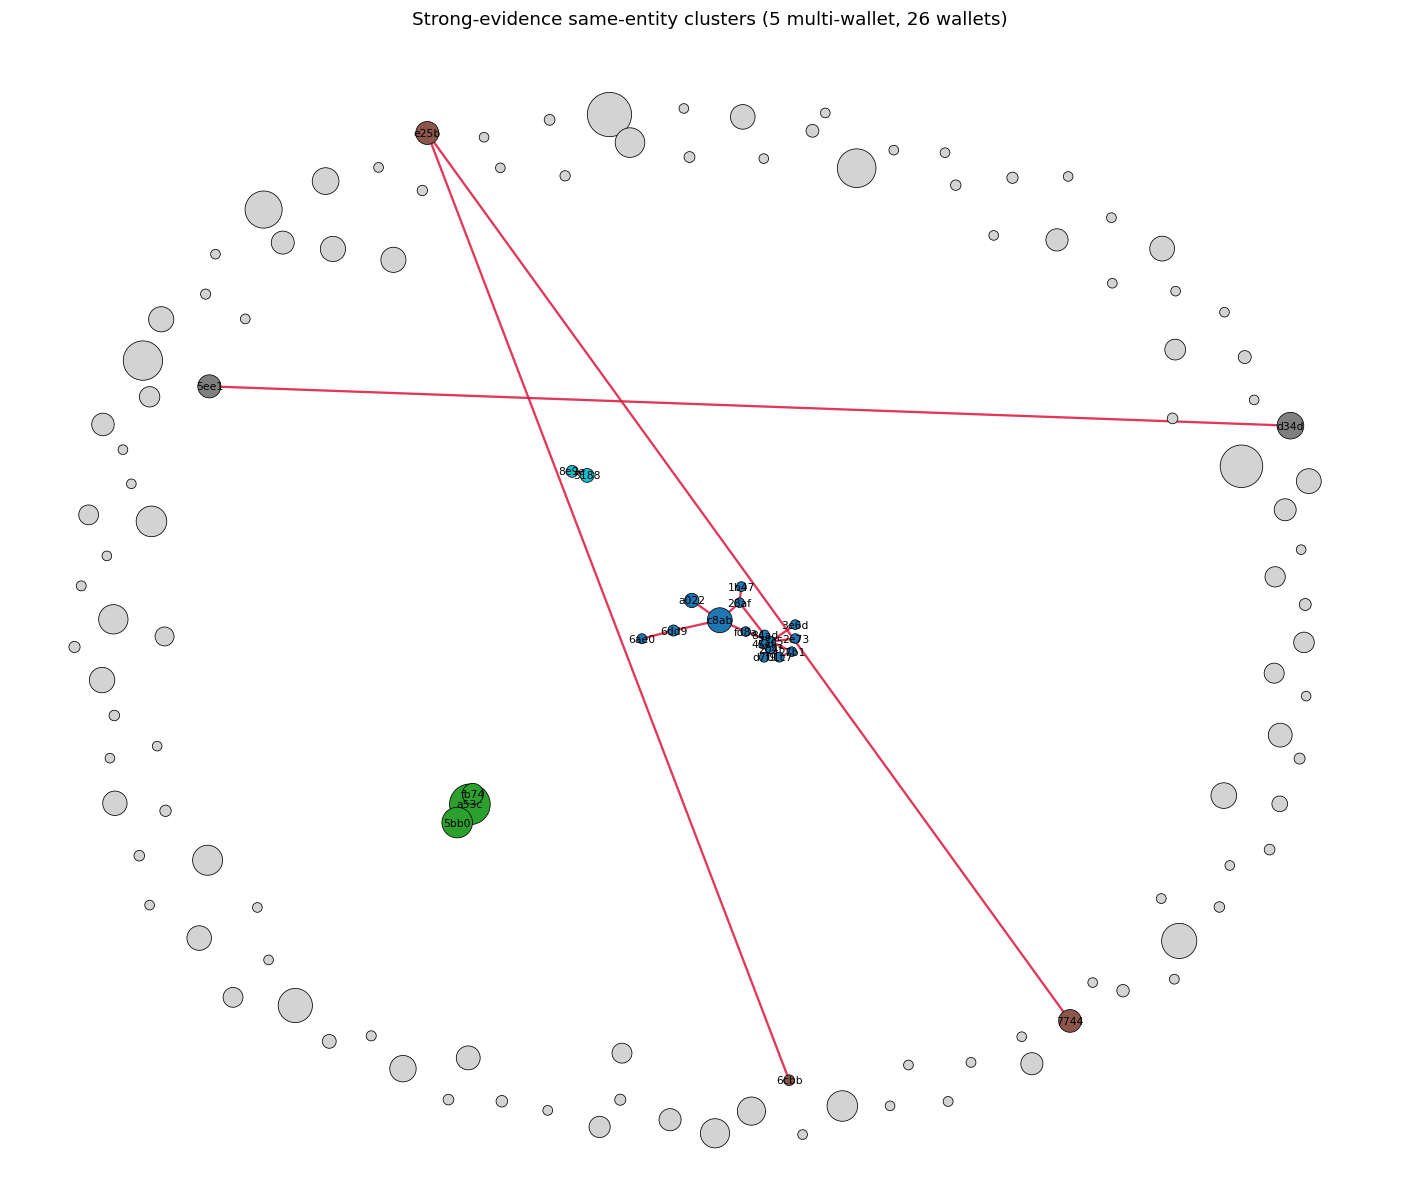

In [12]:
# Same spring-layout style as the full-graph view, but only the strong
# edges are drawn. Layout uses `erc1155_count` as the attraction weight so
# wallets that exchanged many position tokens cluster tightly together.
# Same colouring scheme: each strong-evidence connected component gets a
# distinct colour; nodes that didn't survive the filter stay light grey.
if g_strong.number_of_edges() > 0:
    pos_s = nx.spring_layout(g_strong, weight='erc1155_count', seed=42,
                              k=2.0/np.sqrt(g_strong.number_of_nodes()))
else:
    pos_s = nx.random_layout(g_strong, seed=42)

comp_id = {}
for i, comp in enumerate(sorted(comps, key=len, reverse=True)):
    for n in comp:
        comp_id[n] = i
cmap = plt.cm.tab10(np.linspace(0, 1, max(len(comps), 5)))
node_colors = [cmap[comp_id[n]] if n in comp_id else 'lightgray' for n in g_strong.nodes]
node_sizes = [40 + 800 * (u.loc[n, 'total_notional'] / max_n
                          if n in u.index and pd.notna(u.loc[n, 'total_notional']) else 0)
              for n in g_strong.nodes]

fig, ax = plt.subplots(figsize=(13, 11))
nx.draw_networkx_edges(g_strong, pos_s, edge_color='crimson', width=1.5, alpha=0.85, ax=ax)
nx.draw_networkx_nodes(g_strong, pos_s, node_color=node_colors, node_size=node_sizes,
                       edgecolors='black', linewidths=0.5, ax=ax)
labels = {n: n[2:6] for n in comp_id}
nx.draw_networkx_labels(g_strong, pos_s, labels=labels, font_size=7, ax=ax)
ax.set_title(f'Strong-evidence same-entity clusters '
             f'({len(comps)} multi-wallet, {sum(len(c) for c in comps)} wallets)')
ax.set_axis_off()
plt.tight_layout()

### How concentrated is the top-skill leaderboard once entities collapse?

The most striking finding from the strong-evidence clusters is that the wallets with the highest Bayesian calibration gaps — the apparent "skill leaders" from notebook 1 — are dominated by **one** strong-evidence component. If true, the per-wallet skill leaderboard was always an entity leaderboard in disguise: a few actors with many proxies, not a population of independent skilled traders.

To verify, re-derive the skill ranking after collapsing wallets to entities. We pool the Beta posteriors:

`α_entity = Σ α_wallet`, `β_entity = Σ β_wallet`

which is the correct way to combine independent Beta-Binomial evidence for the same underlying parameter. If the entity is genuinely one actor, the pooled posterior is the right description of its skill; if it isn't, the entity is just a partition we're imposing and the pooled posterior over-states evidence — but the *ranking* across entities still tells us where the skill mass is concentrated.

In [13]:
# Build the bets view in the in-memory DuckDB, recompute per-wallet skill,
# then aggregate to the strong-entity level by pooling Beta posteriors.
# `posterior_alpha_entity = Σ posterior_alpha_wallet`, same for beta — this
# treats each wallet's evidence as independent observations of the same
# entity-level hit-rate parameter.
from intellifi.skill import build_bets_view, wallet_skill, SkillConfig
build_bets_view(con)
ws = wallet_skill(con, cfg=SkillConfig(min_trades=20, prior_strength=4.0)).df()

wallet_to_strong = {}
for i, comp in enumerate(comps):
    for w in comp:
        wallet_to_strong[w] = f'entity_{i}'

def entity_of(w):
    # Non-clustered wallets remain "themselves" — each is its own entity
    # in the entity-level ranking.
    return wallet_to_strong.get(w, w)

ws['entity'] = ws['proxy_wallet'].map(entity_of)

# Pool Beta posteriors at entity level.
entity_skill = (ws.groupby('entity')
                 .agg(n_wallets=('proxy_wallet', 'count'),
                      n_trades=('n_trades', 'sum'),
                      total_notional=('total_notional', 'sum'),
                      posterior_alpha=('posterior_alpha', 'sum'),
                      posterior_beta=('posterior_beta', 'sum'),
                      mean_implied_p=('mean_implied_p', 'mean'))
                 .reset_index())
entity_skill['posterior_mean'] = entity_skill['posterior_alpha'] / (
    entity_skill['posterior_alpha'] + entity_skill['posterior_beta'])
entity_skill['calibration_gap'] = entity_skill['posterior_mean'] - entity_skill['mean_implied_p']

print('Top-10 skill ranking after entity collapse:')
top_entity = (entity_skill.sort_values('calibration_gap', ascending=False)
              .head(10)[['entity', 'n_wallets', 'n_trades',
                         'mean_implied_p', 'posterior_mean', 'calibration_gap']])
top_entity

Top-10 skill ranking after entity collapse:


,entity,n_wallets,n_trades,mean_implied_p,posterior_mean,calibration_gap
54,0x0aea1457048c93959345a57d2de56fbf173179c1,1,23,0.343086,0.997862,0.654775
1026,0xcd0dcf03cd687a904a7dbcf01b42d37995bc7ec8,1,20,0.449757,0.999655,0.549898
942,0xbae50178b9b59459b718658fa4e1f57a95a245e3,1,26,0.174818,0.499265,0.324447
1219,0xefde78f38169634477f6ff46572128b6d21a6505,1,25,0.673427,0.997721,0.324294
1174,0xe8d730c4bc8b6961d59f07a93b460016f5b89d1c,1,22,0.785783,0.999971,0.214187
382,0x4d840f893614877da74db906018450afba0e21b1,1,62,0.640549,0.853549,0.213000
393,0x4f2ba33b080882c0f6b296f48cfd07b6c326f448,1,100,0.810807,0.999976,0.189169
1149,0xe3479950ef6e8984df109ec5c9be40630f9fb438,1,43,0.810656,0.999685,0.189028
909,0xb49f468c15c49783f2664c7198a4949ade1b12e6,1,57,0.806352,0.983245,0.176893
120,0x17525891a4ed52520ad75dac8ed5f32a58be7993,1,86,0.839617,0.999755,0.160138


## Behavioural cross-check — co-trading patterns

### Rationale

The on-chain graph tells us where **capital** flowed. Co-trading tells us where **decisions** flowed. The two are independent in principle (one wallet can trade in lockstep with another without ever exchanging funds, e.g. a copy-trading bot, or vice versa), so finding the same wallets clustered by both signals is much stronger evidence of common operation than either signal alone.

### What we compute (`scripts/04_coordination_analysis.py`)

* **`cotrade_pairs`** — pairs of universe wallets that traded the same `asset_id` on the same side within a 5-minute bucket. Counted across all 100 markets and aggregated to a weighted edge list. Pairs with ≥3 co-events are reported.
* **`leader_lag`** — directed lead-follower relationships. For each ordered pair (A, B), the LEAD window function finds events where A traded an asset and B traded the same asset+side within 10 minutes. Pairs with ≥5 lead events are reported, with the median lag in seconds.
* **`wash_round_trips`** — wallets that BUY-then-SELL the same asset within 10 minutes with ≥50% size overlap. Single-wallet pattern, but listed here because wash-trading is one of the manipulation patterns the spec calls out.
* **`behavioural_partition`** — Louvain communities on the weighted co-trade graph. Stored as a JSON mapping wallet → community_id.

### Cross-check logic

1. For each on-chain strong-evidence entity, look at the distribution of *behavioural* community ids its members fall into. If they cluster in one community, the two signals converge.
2. Conversely, for each behavioural community with multiple members, count how many are in the top-50 by notional / PnL / skill. A community with many top-skill wallets is the candidate for "this skill cluster is coordinated".

### What we expect

* **Independent signals → independent partitions.** If on-chain entities and behavioural communities were unrelated, on-chain entity #i would be spread roughly uniformly across many behavioural communities, with no community containing more than 1–2 members.
* **Same actor → both signals converge.** A specific behavioural community contains a strong majority of an on-chain entity's wallets. This is what we actually see for entity #0 vs community #65 (11/16 members shared).

In [14]:
# Load the coordination artefacts and print headline counts.
# `cotrade_pairs` is the co-trading edge list (asset_id × side × 5-min bucket
# expanded into pairwise events, then aggregated). `leader_lag` captures
# directed lead-follower patterns with median lag. `wash_round_trips` is the
# per-wallet self-roundtrip count. `behavioural_partition` is the Louvain
# partition over the co-trading graph.
import json as _json
ct = pd.read_parquet(config.PARQUET_DIR / 'coordination' / 'cotrade_pairs.parquet')
ll = pd.read_parquet(config.PARQUET_DIR / 'coordination' / 'leader_lag.parquet')
wt = pd.read_parquet(config.PARQUET_DIR / 'coordination' / 'wash_round_trips.parquet')
beh_part = _json.loads((config.PARQUET_DIR / 'coordination' / 'behavioural_partition.json').read_text())

print(f'co-trade pairs (>=3 events, 5-min window): {len(ct)}')
print(f'leader→follower pairs (>=5 events, <=10-min lag): {len(ll)}')
print(f'wallets with wash round-trip candidates: {len(wt)}')

# Behavioural community size distribution.
from collections import Counter as _C
sizes = _C(_C(beh_part.values()).values())
print(f'behavioural communities: {len(set(beh_part.values()))} ({sum(1 for c, n in _C(beh_part.values()).items() if n >= 2)} multi-wallet)')
print(f'size distribution: {dict(sorted(sizes.items()))}')
print()
print('top 10 co-trading pairs:')
ct.head(10)

co-trade pairs (>=3 events, 5-min window): 130
leader→follower pairs (>=5 events, <=10-min lag): 61
wallets with wash round-trip candidates: 19
behavioural communities: 91 (11 multi-wallet)
size distribution: {1: 80, 2: 7, 4: 1, 5: 1, 13: 1, 18: 1}

top 10 co-trading pairs:


,a,b,cotrade_events,cotrade_markets,cotrade_buckets,combined_bucket_notional
0,0x67bc6af6806df61ba5144b125174ecf5f821d54e,0xd218e474776403a330142299f7796e8ba32eb5c9,22,4,19,85424.486063
1,0x4f2ba33b080882c0f6b296f48cfd07b6c326f448,0xd218e474776403a330142299f7796e8ba32eb5c9,20,2,20,113452.888040
2,0x0e3d0bfb5f051d160c12aa8ec37f9b49c8fbc58d,0xd218e474776403a330142299f7796e8ba32eb5c9,17,2,16,180113.866300
3,0x1217832819e321d21f4e5a27c62b8ec6ad845d72,0xd218e474776403a330142299f7796e8ba32eb5c9,17,2,17,2969.298300
4,0x204f72f35326db932158cba6adff0b9a1da95e14,0x2e73b22d89cf192a64e7fde40ae4111199603f4e,16,1,14,115111.382116
5,0x34228aaab0de1e3860c1755a06c3d3eaa416cd99,0xd218e474776403a330142299f7796e8ba32eb5c9,16,1,14,27437.363296
6,0xb49f468c15c49783f2664c7198a4949ade1b12e6,0xd218e474776403a330142299f7796e8ba32eb5c9,15,5,14,89085.630260
7,0xd218e474776403a330142299f7796e8ba32eb5c9,0xe069d0d68bb556f8fe7f7229f17b5dbe6a833c17,13,4,10,89161.932520
8,0x1217832819e321d21f4e5a27c62b8ec6ad845d72,0x8e9eedf20dfa70956d49f608a205e402d9df38e4,13,2,10,46456.824200
9,0x426ad8df074058e04606afbe4234747e83471376,0xca165e655b0506ee83678157ea12bf62a450f878,13,5,13,1367.096237


In [15]:
# The cross-check.
# Forward pass: for each on-chain strong-evidence entity, count how its
# members partition across behavioural communities. If one community holds
# a strong majority, the two independent signals converge — the strongest
# possible evidence we can produce for "these wallets are one actor".
print('=== Are on-chain strong-evidence entities also behaviourally coordinated? ===\n')
for i, comp in enumerate(sorted(comps, key=len, reverse=True)):
    comm_dist = _C(beh_part[w] for w in comp if w in beh_part)
    largest_share = max(comm_dist.values()) if comm_dist else 0
    print(f'on-chain entity #{i} ({len(comp)} wallets):')
    print(f'  spread across {len(comm_dist)} behavioural communities')
    print(f'  largest single community contains {largest_share}/{len(comp)} '
          f'({largest_share / len(comp):.0%}) of entity members')
    print()

# Reverse pass: which behavioural communities are dense with skill leaders?
# A community whose members are heavily ranked in top-50 by skill is the
# place where "coordinated trading" overlaps "apparent edge" — the prime
# candidate for "this is an informed actor running multiple proxies".
print('=== Behavioural communities by skill concentration ===')
rows = []
for comm_id in sorted(set(beh_part.values())):
    members = [w for w, c in beh_part.items() if c == comm_id]
    if len(members) < 2:
        continue
    sub = u.loc[u.index.intersection(members)]
    rows.append({
        'community_id': comm_id,
        'size': len(members),
        'total_notional': sub['total_notional'].sum(),
        'total_pnl': sub['realised_pnl'].sum(),
        'in_top_notional': sub['rk_notional'].notna().sum(),
        'in_top_pnl': sub['rk_pnl'].notna().sum(),
        'in_top_skill': sub['rk_skill'].notna().sum(),
    })
beh_summary = pd.DataFrame(rows).sort_values('in_top_skill', ascending=False)
print(beh_summary.head(10).to_string(index=False))

=== Are on-chain strong-evidence entities also behaviourally coordinated? ===

on-chain entity #0 (16 wallets):
  spread across 6 behavioural communities
  largest single community contains 11/16 (69%) of entity members

on-chain entity #1 (3 wallets):
  spread across 3 behavioural communities
  largest single community contains 1/3 (33%) of entity members

on-chain entity #2 (3 wallets):
  spread across 3 behavioural communities
  largest single community contains 1/3 (33%) of entity members

on-chain entity #3 (2 wallets):
  spread across 2 behavioural communities
  largest single community contains 1/2 (50%) of entity members

on-chain entity #4 (2 wallets):
  spread across 2 behavioural communities
  largest single community contains 1/2 (50%) of entity members

=== Behavioural communities by skill concentration ===
 community_id  size  total_notional      total_pnl  in_top_notional  in_top_pnl  in_top_skill
           27    18    8.497647e+06 -363270.979633                3       

In [16]:
# Leader-lag patterns. A wallet pair with many lead events and a very
# small median lag (e.g. <5s) is almost certainly the same operator
# running a multi-wallet bot — humans don't reliably react to each other
# in single-digit seconds, but a script firing identical orders to two
# proxies can. The lag distribution is therefore another forensic angle.
print('Top 15 leader→follower pairs by event count:')
print(ll.sort_values('lead_events', ascending=False).head(15).to_string(index=False))

print('\nPairs with median lag <= 5 seconds (likely same-actor multi-wallet bot):')
tight = ll[ll['median_lag_seconds'] <= 5.0].sort_values('lead_events', ascending=False)
print(tight.head(20).to_string(index=False))

Top 15 leader→follower pairs by event count:
                                    leader                                   follower  lead_events  lead_markets  mean_lag_seconds  median_lag_seconds
0x1217832819e321d21f4e5a27c62b8ec6ad845d72 0xd218e474776403a330142299f7796e8ba32eb5c9           23             2        159.478261                52.0
0x1217832819e321d21f4e5a27c62b8ec6ad845d72 0x8e9eedf20dfa70956d49f608a205e402d9df38e4           21             2         57.333333                 4.0
0x67bc6af6806df61ba5144b125174ecf5f821d54e 0xd218e474776403a330142299f7796e8ba32eb5c9           20             2         43.300000                13.0
0xd218e474776403a330142299f7796e8ba32eb5c9 0x67bc6af6806df61ba5144b125174ecf5f821d54e           19             2         64.000000                 4.0
0x0e3d0bfb5f051d160c12aa8ec37f9b49c8fbc58d 0xd218e474776403a330142299f7796e8ba32eb5c9           19             2         93.421053                46.0
0x8e9eedf20dfa70956d49f608a205e402d9df38e4 0x1217

In [17]:
# Wash-trade candidates. The self-join in scripts/04_coordination_analysis.py
# finds wallets that BUY then SELL (or SELL then BUY) the same asset within
# 10 minutes with significant size overlap. This pattern can be benign
# (closing a position to lock PnL after a price move) or suspicious (wash
# trading to create the appearance of volume / liquidity / momentum).
# Cross-referencing against `total_notional` and `realised_pnl` lets us
# spot wallets where round-trip activity is a large share of their footprint.
print('Wash-trade candidates (BUY→SELL same asset within 10 min, ≥50% size overlap):')
wt_with_meta = wt.merge(u.reset_index()[['proxy_wallet', 'total_notional', 'realised_pnl']],
                        on='proxy_wallet', how='left')
print(wt_with_meta.sort_values('round_trips', ascending=False).head(15).to_string(index=False))

Wash-trade candidates (BUY→SELL same asset within 10 min, ≥50% size overlap):
                              proxy_wallet  round_trips  round_trip_assets  mean_gap_seconds  round_trip_notional  total_notional  realised_pnl
0xca8e9533bf61136f39c31e76e36b2087c3dca742          138                  9        378.884058        970771.663000    3.472259e+06  -1691.100610
0x28af10854ed0c6d940cd79e017102fa749427de0           72                  1        307.083333           109.309989    6.529999e+01     46.114442
0xe069d0d68bb556f8fe7f7229f17b5dbe6a833c17           42                  3        114.904762           894.510000    1.315540e+03     94.780000
0x3e6d998a25793c1d0ca5b59d7d7ac7f8d0132671           27                  2        175.629630            94.480683    2.013252e+02     85.869219
0x34228aaab0de1e3860c1755a06c3d3eaa416cd99           24                  1        312.916667            32.832400    1.431149e+02     22.369890
0x73c5701afdefba2814193168448b2992306b2f80           19   